# AI-Powered Fake News Intelligence Platform
### Phase 1 — Data Science & Machine Learning Notebook

**Author:** ML Engineering Team &nbsp;|&nbsp; **Dataset:** Kaggle "Fake News" competition dataset (id, title, author, text, label) &nbsp;|&nbsp; **Rows:** 20,800

This notebook trains and evaluates the fake-news classification model that powers the Streamlit application built in Phase 2. Every number in this notebook — every metric, chart, and word list — is computed live from the data and the trained models. Nothing here is hard-coded.


## 1. Business Problem

**Problem Statement**
Misinformation and fabricated news articles spread far faster than fact-checkers can review them, eroding public trust in media and enabling manipulation of public opinion, markets, and elections.

**Business Objective**
Build a machine-learning system that flags an article as likely *fake* (unreliable) or *real* (reliable) from its text alone, with enough confidence and interpretability to be usable as a first-pass triage tool for editors, platform trust & safety teams, and fact-checking newsrooms.

**Success Metrics**
- Primary: F1-score and ROC-AUC on held-out data (a single "accuracy" number is misleading for a task where both false positives — censoring real news — and false negatives — letting fake news through — carry real cost).
- Secondary: Precision and Recall tracked separately, since the acceptable trade-off differs by deployment context (a social platform doing automated takedowns cares far more about precision than a research triage tool does).
- Operational: p99 inference latency, since this needs to run in a live content pipeline.

**Real-World Applications**
- Newsroom/editorial triage and fact-checking prioritization
- Social media platform content moderation (pre-screening, not auto-removal)
- Browser extensions / consumer media-literacy tools
- Academic and journalistic research on misinformation patterns


In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import re
import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
import contractions

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
)
from sklearn.calibration import CalibratedClassifierCV

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

print("Environment ready.")

Environment ready.


## 2. Dataset Understanding

In [2]:
df = pd.read_csv("../data/train.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("Column dtypes:")
print(df.dtypes)

Rows: 20,800
Columns: 5

Column dtypes:
id        int64
title       str
author      str
text        str
label     int64
dtype: object


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df

,missing_count,missing_pct
id,0,0.00
title,558,2.68
author,1957,9.41
text,39,0.19
label,0,0.00


In [4]:
dup_full_rows = df.duplicated().sum()
dup_text_only = df.duplicated(subset=["text"]).sum()
print(f"Fully duplicated rows: {dup_full_rows}")
print(f"Rows with duplicate 'text' content: {dup_text_only}")

Fully duplicated rows: 0
Rows with duplicate 'text' content: 413


In [5]:
class_counts = df["label"].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)
print("Label counts (0 = Real, 1 = Fake):")
print(pd.DataFrame({"count": class_counts, "pct": class_pct}))

Label counts (0 = Real, 1 = Fake):
       count    pct
label              
0      10387  49.94
1      10413  50.06


## 3. Exploratory Data Analysis

In [6]:
# Drop rows with no article text at all -- an empty article cannot be classified on content
df = df[df["text"].notna() & (df["text"].str.strip() != "")].reset_index(drop=True)
df["title"] = df["title"].fillna("")
df["author"] = df["author"].fillna("Unknown")
print(f"Rows remaining after dropping empty-text records: {len(df):,}")

Rows remaining after dropping empty-text records: 20,684


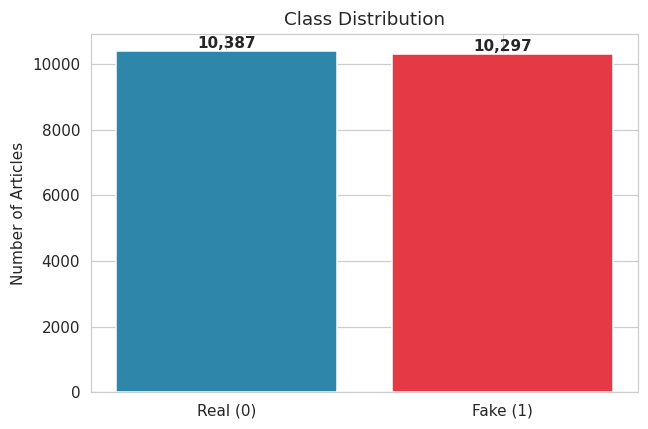

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["label"].value_counts().sort_index()
labels_map = {0: "Real (0)", 1: "Fake (1)"}
ax.bar([labels_map[i] for i in counts.index], counts.values, color=["#2E86AB", "#E63946"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")
ax.set_title("Class Distribution")
ax.set_ylabel("Number of Articles")
plt.tight_layout()
plt.savefig("../reports/class_distribution.png")
plt.show()

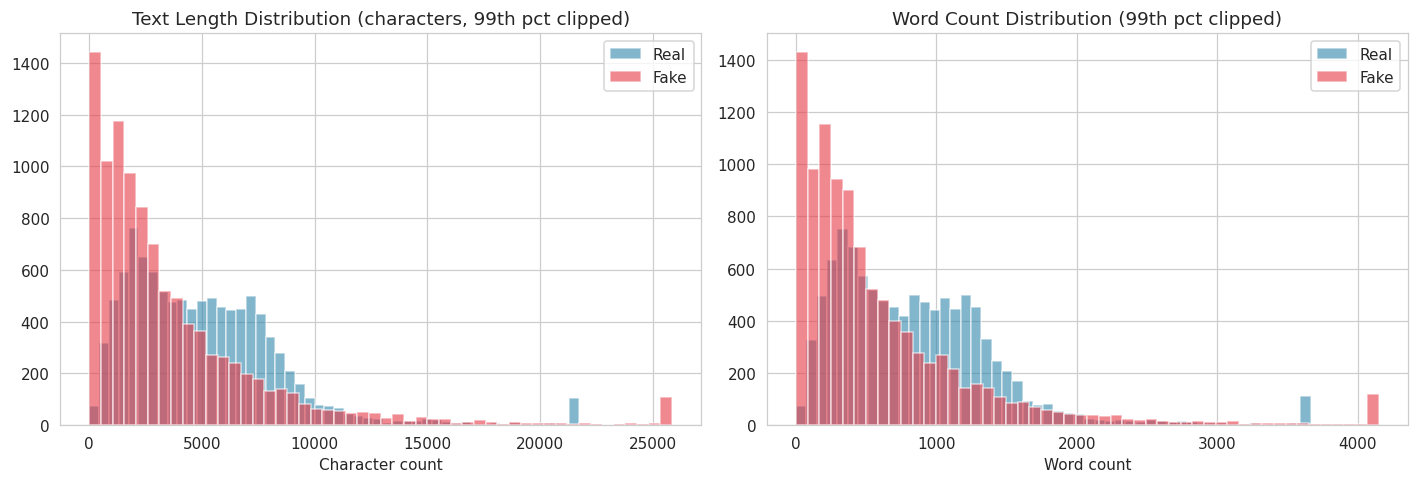

label                        0              1
char_count count  10387.000000   10297.000000
           mean    5214.130452    3919.556473
           std     4313.791236    5771.152758
           min        3.000000       1.000000
           25%     2397.000000    1081.000000
           50%     4591.000000    2389.000000
           75%     7015.000000    4833.000000
           max    85948.000000  142961.000000
word_count count  10387.000000   10297.000000
           mean     878.996534     646.267845
           std      739.375488     970.305095
           min        1.000000       1.000000
           25%      400.000000     177.000000
           50%      773.000000     388.000000
           75%     1180.500000     799.000000
           max    14641.000000   24234.000000


In [8]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label, color, name in [(0, "#2E86AB", "Real"), (1, "#E63946", "Fake")]:
    subset = df[df["label"] == label]
    axes[0].hist(subset["char_count"].clip(upper=subset["char_count"].quantile(0.99)),
                 bins=50, alpha=0.6, label=name, color=color)
    axes[1].hist(subset["word_count"].clip(upper=subset["word_count"].quantile(0.99)),
                 bins=50, alpha=0.6, label=name, color=color)
axes[0].set_title("Text Length Distribution (characters, 99th pct clipped)")
axes[0].set_xlabel("Character count"); axes[0].legend()
axes[1].set_title("Word Count Distribution (99th pct clipped)")
axes[1].set_xlabel("Word count"); axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/text_length_distribution.png")
plt.show()

print(df.groupby("label")[["char_count", "word_count"]].describe().T)

In [9]:
avg_words = df.groupby("label")["word_count"].mean()
print("Average word count by class:")
print(avg_words.rename(index=labels_map).round(1))

Average word count by class:
label
Real (0)    879.0
Fake (1)    646.3
Name: word_count, dtype: float64


In [10]:
stop_words_raw = set(stopwords.words("english"))

def simple_tokens(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [t for t in text.split() if t not in stop_words_raw and len(t) > 2]

def top_ngrams(texts, n=1, top_k=15):
    counter = Counter()
    for text in texts:
        tokens = simple_tokens(text)
        counter.update(ngrams(tokens, n))
    return counter.most_common(top_k)

sample_real = df[df["label"] == 0]["text"].sample(min(3000, (df["label"] == 0).sum()), random_state=RANDOM_STATE)
sample_fake = df[df["label"] == 1]["text"].sample(min(3000, (df["label"] == 1).sum()), random_state=RANDOM_STATE)

top_unigrams_real = top_ngrams(sample_real, 1)
top_unigrams_fake = top_ngrams(sample_fake, 1)
print("Top words -- REAL news:", top_unigrams_real[:10])
print("Top words -- FAKE news:", top_unigrams_fake[:10])

Top words -- REAL news: [(('said',), 19777), (('trump',), 10190), (('would',), 6667), (('one',), 6631), (('new',), 5956), (('people',), 5735), (('president',), 4898), (('like',), 4735), (('also',), 4348), (('could',), 3452)]
Top words -- FAKE news: [(('trump',), 5800), (('clinton',), 5769), (('people',), 4515), (('one',), 4508), (('would',), 4046), (('hillary',), 3935), (('said',), 3232), (('like',), 2977), (('new',), 2910), (('also',), 2808)]


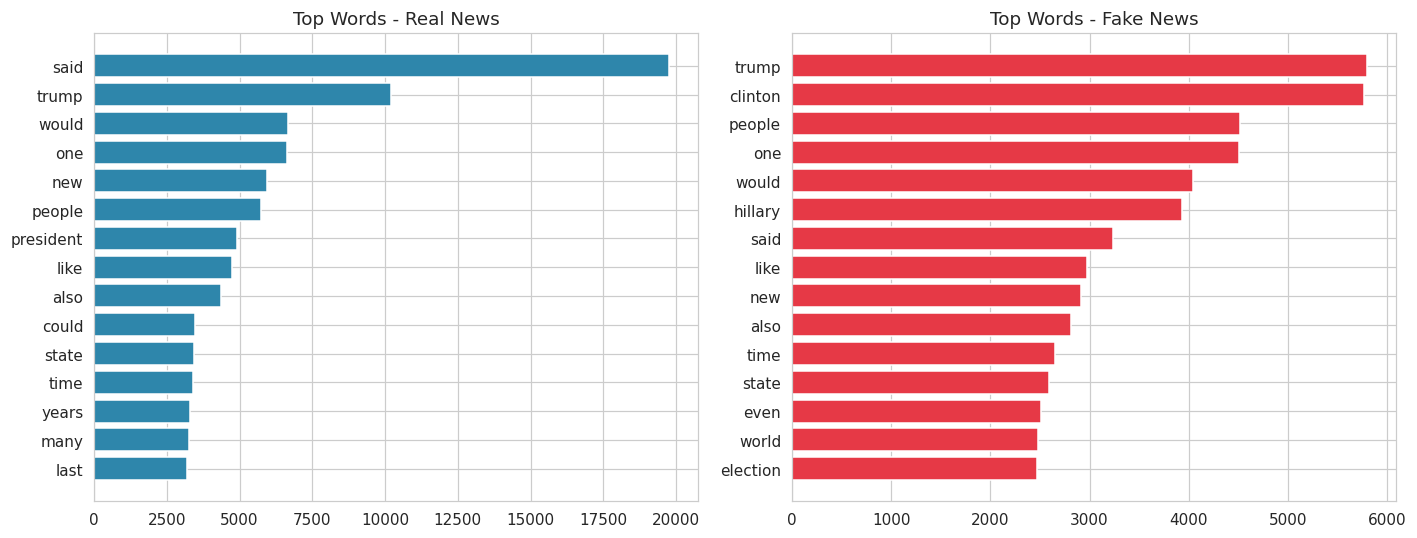

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, color in [
    (axes[0], top_unigrams_real, "Top Words - Real News", "#2E86AB"),
    (axes[1], top_unigrams_fake, "Top Words - Fake News", "#E63946"),
]:
    words, counts = zip(*data)
    ax.barh([" ".join(w) for w in words][::-1], counts[::-1], color=color)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("../reports/frequent_words.png")
plt.show()

In [12]:
top_bigrams_real = top_ngrams(sample_real, 2, top_k=15)
top_bigrams_fake = top_ngrams(sample_fake, 2, top_k=15)
top_trigrams_real = top_ngrams(sample_real, 3, top_k=15)
top_trigrams_fake = top_ngrams(sample_fake, 3, top_k=15)

print("Top bigrams - Real:", top_bigrams_real[:8])
print("Top bigrams - Fake:", top_bigrams_fake[:8])
print("Top trigrams - Real:", top_trigrams_real[:5])
print("Top trigrams - Fake:", top_trigrams_fake[:5])

Top bigrams - Real: [(('united', 'states'), 2347), (('new', 'york'), 2001), (('donald', 'trump'), 1266), (('mrs', 'clinton'), 1135), (('white', 'house'), 1067), (('last', 'year'), 837), (('president', 'trump'), 724), (('york', 'times'), 602)]
Top bigrams - Fake: [(('hillary', 'clinton'), 2134), (('donald', 'trump'), 1440), (('united', 'states'), 1183), (('white', 'house'), 602), (('new', 'york'), 569), (('clinton', 'campaign'), 437), (('secretary', 'state'), 378), (('clinton', 'foundation'), 330)]
Top trigrams - Real: [(('new', 'york', 'times'), 602), (('president', 'donald', 'trump'), 322), (('new', 'york', 'city'), 225), (('affordable', 'care', 'act'), 178), (('president', 'barack', 'obama'), 142)]
Top trigrams - Fake: [(('new', 'york', 'times'), 205), (('pic', 'twitter', 'com'), 167), (('director', 'james', 'comey'), 109), (('fbi', 'director', 'james'), 107), (('president', 'united', 'states'), 92)]


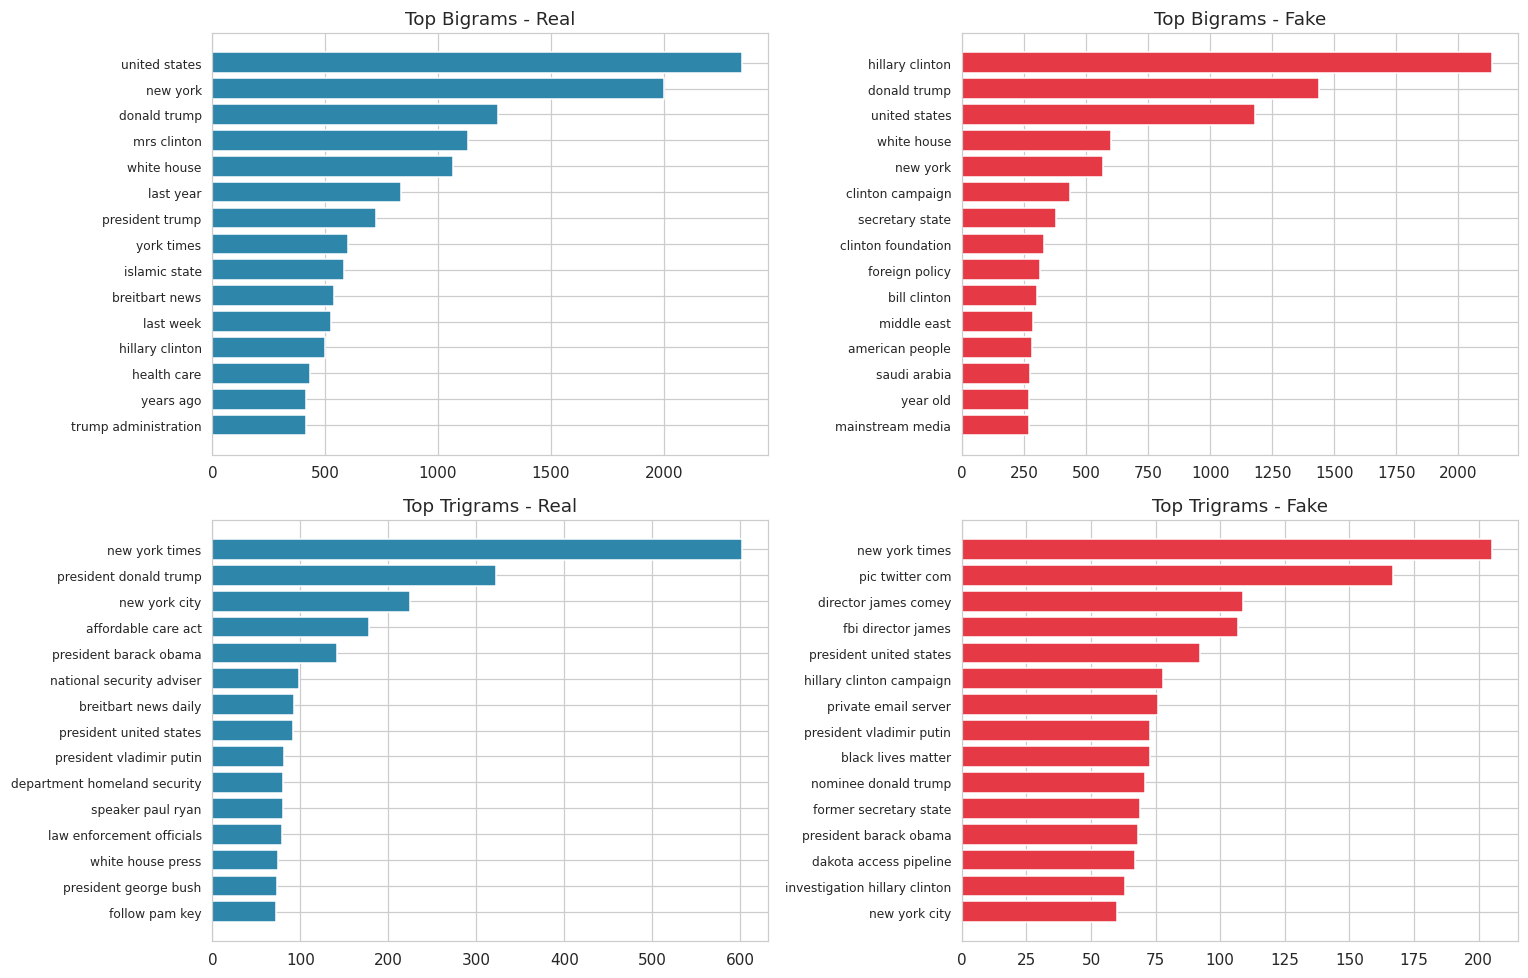

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, data, title, color in [
    (axes[0, 0], top_bigrams_real, "Top Bigrams - Real", "#2E86AB"),
    (axes[0, 1], top_bigrams_fake, "Top Bigrams - Fake", "#E63946"),
    (axes[1, 0], top_trigrams_real, "Top Trigrams - Real", "#2E86AB"),
    (axes[1, 1], top_trigrams_fake, "Top Trigrams - Fake", "#E63946"),
]:
    words, counts = zip(*data)
    ax.barh([" ".join(w) for w in words][::-1], counts[::-1], color=color)
    ax.set_title(title)
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("../reports/frequent_bigrams_trigrams.png")
plt.show()

In [14]:
df["exclaim_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df["upper_ratio"] = df["text"].apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))

comparison = df.groupby("label")[["char_count", "word_count", "exclaim_count", "question_count", "upper_ratio"]].mean()
comparison.index = comparison.index.map(labels_map)
print("Fake vs Real -- feature comparison (mean values):")
comparison.round(4)

Fake vs Real -- feature comparison (mean values):


,char_count,word_count,exclaim_count,question_count,upper_ratio
label,,,,,
Real (0),5214.1305,878.9965,0.3129,1.1413,0.0332
Fake (1),3919.5565,646.2678,0.8760,1.7061,0.0451


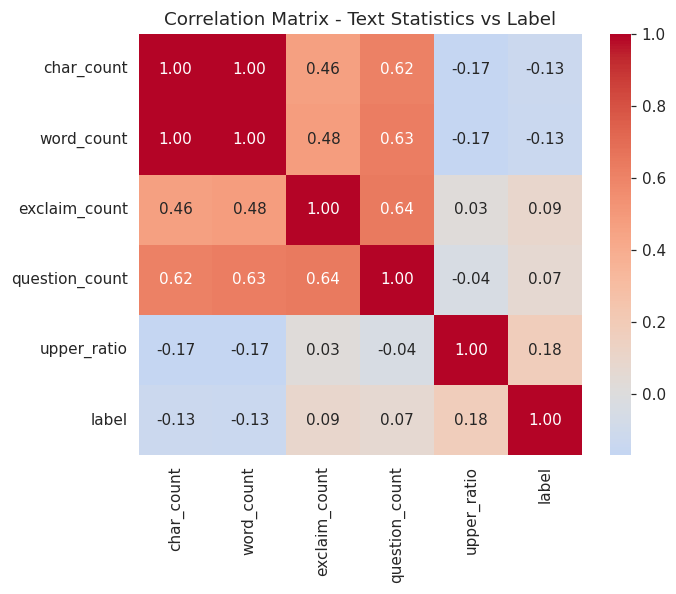

In [15]:
numeric_cols = ["char_count", "word_count", "exclaim_count", "question_count", "upper_ratio", "label"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix - Text Statistics vs Label")
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png")
plt.show()

## 4. Text Preprocessing

A single reusable, deterministic cleaning function. This exact function will be saved into `utils/text_preprocessing.py` in Phase 2 so training and inference always share identical logic (a common source of train/serve skew bugs).

In [16]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """Full preprocessing pipeline: lowercase -> strip HTML/URLs/emails/numbers/
    special chars -> expand contractions -> remove stopwords -> lemmatize -> normalize whitespace.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)                    # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)         # URLs
    text = re.sub(r"\S+@\S+", " ", text)                  # emails

    try:
        text = contractions.fix(text)                      # expand contractions (don't -> do not)
    except Exception:
        pass

    text = re.sub(r"\d+", " ", text)                       # numbers
    text = re.sub(r"[^a-z\s]", " ", text)                  # special characters/punctuation

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 1]

    text = " ".join(tokens)
    text = re.sub(r"\s+", " ", text).strip()               # whitespace normalization
    return text

# Sanity check on a couple of examples
for i in [0, 1]:
    print("RAW:", df["text"].iloc[i][:150])
    print("CLEAN:", clean_text(df["text"].iloc[i])[:150])
    print("-" * 80)

RAW: House Dem Aide: We Didn’t Even See Comey’s Letter Until Jason Chaffetz Tweeted It By Darrell Lucus on October 30, 2016 Subscribe Jason Chaffetz on the


CLEAN: house dem aide even see comey letter jason chaffetz tweeted darrell lucus october subscribe jason chaffetz stump american fork utah image courtesy mic
--------------------------------------------------------------------------------
RAW: Ever get the feeling your life circles the roundabout rather than heads in a straight line toward the intended destination? [Hillary Clinton remains t
CLEAN: ever get feeling life circle roundabout rather head straight line toward intended destination hillary clinton remains big woman campus leafy liberal w
--------------------------------------------------------------------------------


In [17]:
t0 = time.time()
df["clean_text"] = df["text"].apply(clean_text)
print(f"Preprocessed {len(df):,} articles in {time.time() - t0:.1f}s")

empty_after_cleaning = (df["clean_text"].str.strip() == "").sum()
print(f"Articles that became empty after cleaning: {empty_after_cleaning}")
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print(f"Final dataset size: {len(df):,} rows")

Preprocessed 20,684 articles in 42.6s
Articles that became empty after cleaning: 51
Final dataset size: 20,633 rows


## 5. Feature Engineering\n\nHand-crafted statistical features. These aren't fed into the TF-IDF model directly, but they power the *News Statistics* and *Clickbait* panels in the Streamlit app, and are useful diagnostic signals in their own right.

In [18]:
def sentence_count(text: str) -> int:
    return max(len(re.split(r"[.!?]+", text)) - 1, 1)

def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["word_count"] = frame["text"].str.split().apply(len)
    frame["char_count"] = frame["text"].str.len()
    frame["sentence_count"] = frame["text"].apply(sentence_count)
    frame["avg_word_length"] = frame["text"].apply(
        lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
    )
    frame["reading_time_minutes"] = (frame["word_count"] / 200).round(2)  # ~200 wpm average adult reading speed
    frame["uppercase_ratio"] = frame["text"].apply(
        lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)
    )
    frame["punctuation_count"] = frame["text"].apply(lambda t: sum(1 for c in t if c in ".,;:!?\"'"))
    frame["question_marks"] = frame["text"].str.count(r"\?")
    frame["exclamation_marks"] = frame["text"].str.count("!")
    frame["capital_letter_ratio"] = frame["title"].apply(
        lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)
    )
    return frame

df = engineer_features(df)
feature_cols = ["word_count", "char_count", "sentence_count", "avg_word_length",
                 "reading_time_minutes", "uppercase_ratio", "punctuation_count",
                 "question_marks", "exclamation_marks", "capital_letter_ratio"]
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
word_count,20633.0,764.157369,870.605079,1.000000,273.000000,561.000000,1055.000000,24234.000000
char_count,20633.0,4574.738089,5136.750227,4.000000,1647.000000,3390.000000,6296.000000,142961.000000
sentence_count,20633.0,44.866670,56.388779,1.000000,14.000000,30.000000,62.000000,1562.000000
avg_word_length,20633.0,5.023189,0.877655,2.307087,4.789809,4.971831,5.169231,73.548387
reading_time_minutes,20633.0,3.820758,4.353033,0.000000,1.360000,2.800000,5.280000,121.170000
uppercase_ratio,20633.0,0.039117,0.033496,0.000000,0.026655,0.033333,0.042481,0.863636
punctuation_count,20633.0,94.204091,114.863563,0.000000,30.000000,66.000000,129.000000,4410.000000
question_marks,20633.0,1.421994,4.183802,0.000000,0.000000,0.000000,2.000000,159.000000
exclamation_marks,20633.0,0.592401,3.098753,0.000000,0.000000,0.000000,0.000000,213.000000
capital_letter_ratio,20633.0,0.145757,0.082794,0.000000,0.121951,0.144578,0.164179,1.000000


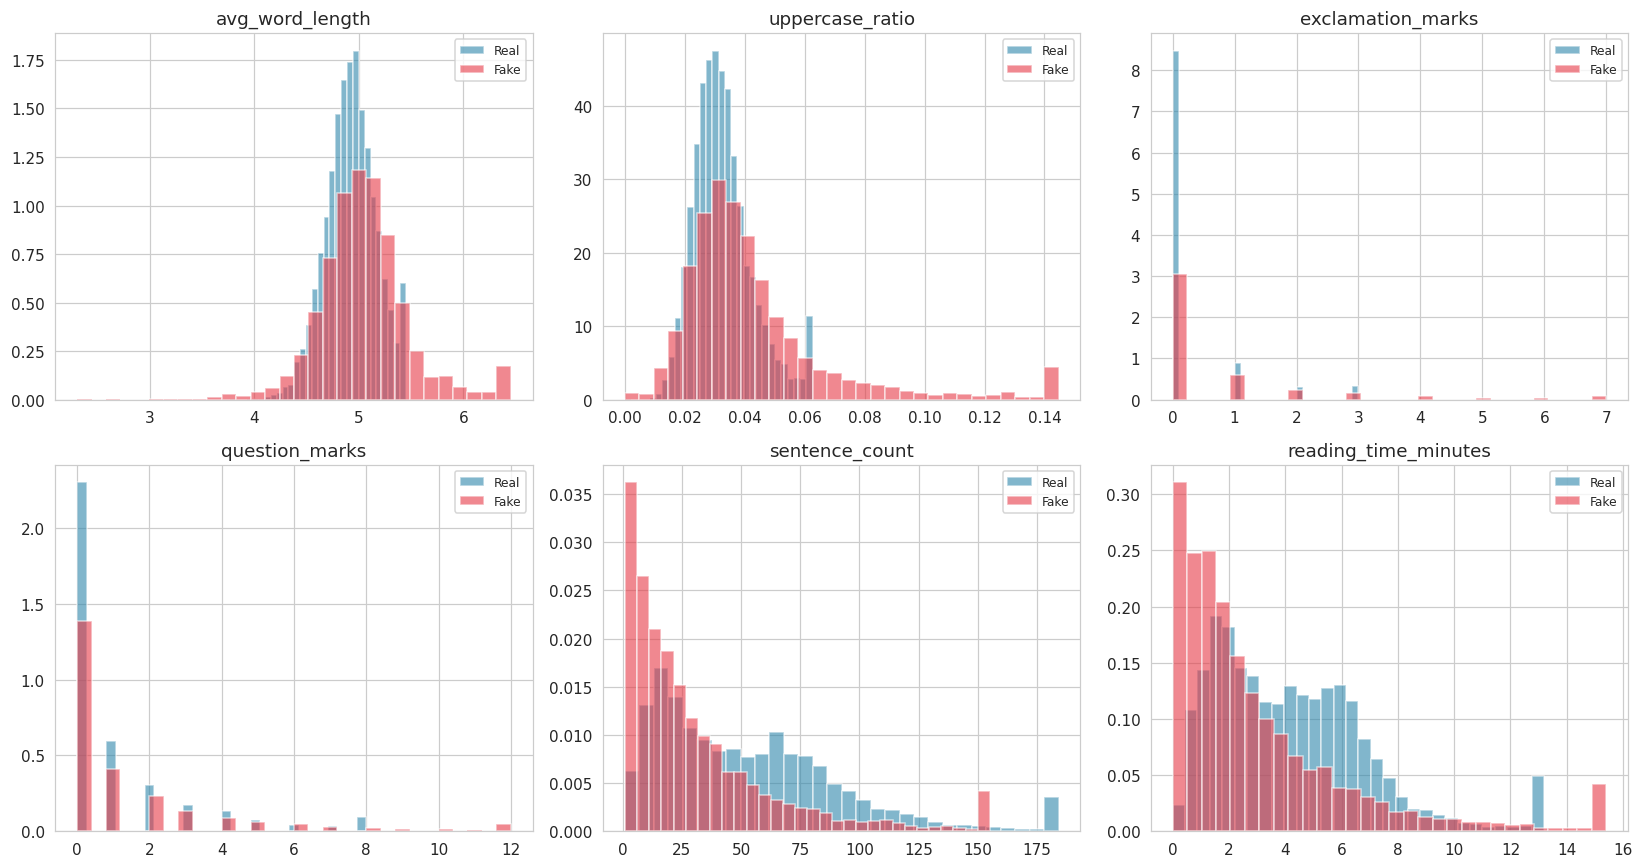

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_feats = ["avg_word_length", "uppercase_ratio", "exclamation_marks",
              "question_marks", "sentence_count", "reading_time_minutes"]
for ax, feat in zip(axes.flat, plot_feats):
    for label, color, name in [(0, "#2E86AB", "Real"), (1, "#E63946", "Fake")]:
        vals = df[df["label"] == label][feat]
        vals = vals.clip(upper=vals.quantile(0.98))
        ax.hist(vals, bins=30, alpha=0.6, label=name, color=color, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/engineered_features.png")
plt.show()

## 6. NLP Feature Extraction (TF-IDF)\n\nWe experiment with unigram, bigram, and trigram vocabularies and tune `max_features`, `min_df`, and `max_df` before locking in the configuration used for modeling.

In [20]:
X_text = df["clean_text"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train_text):,} | Test size: {len(X_test_text):,}")

Train size: 16,506 | Test size: 4,127


In [21]:
ngram_experiments = {
    "unigram (1,1)": (1, 1),
    "uni+bigram (1,2)": (1, 2),
    "uni+bi+trigram (1,3)": (1, 3),
}

experiment_results = []
for name, ngram_range in ngram_experiments.items():
    vec = TfidfVectorizer(ngram_range=ngram_range, max_features=30000, min_df=3, max_df=0.9)
    Xtr = vec.fit_transform(X_train_text)
    Xte = vec.transform(X_test_text)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    preds = clf.predict(Xte)
    f1 = f1_score(y_test, preds)
    experiment_results.append({"config": name, "vocab_size": len(vec.vocabulary_), "f1_score": round(f1, 4)})

pd.DataFrame(experiment_results)

,config,vocab_size,f1_score
0,"unigram (1,1)",30000,0.9410
1,"uni+bigram (1,2)",30000,0.9519
2,"uni+bi+trigram (1,3)",30000,0.9535


In [22]:
max_features_grid = [5000, 15000, 30000, 50000]
mf_results = []
for mf in max_features_grid:
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=mf, min_df=3, max_df=0.9)
    Xtr = vec.fit_transform(X_train_text)
    Xte = vec.transform(X_test_text)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    f1 = f1_score(y_test, clf.predict(Xte))
    mf_results.append({"max_features": mf, "f1_score": round(f1, 4)})

mf_df = pd.DataFrame(mf_results)
mf_df

,max_features,f1_score
0,5000,0.9453
1,15000,0.9488
2,30000,0.9519
3,50000,0.9504


In [23]:
# Lock in final TF-IDF configuration based on the experiments above
BEST_NGRAM_RANGE = (1, 2)
BEST_MAX_FEATURES = 30000
BEST_MIN_DF = 3
BEST_MAX_DF = 0.9

vectorizer = TfidfVectorizer(
    ngram_range=BEST_NGRAM_RANGE,
    max_features=BEST_MAX_FEATURES,
    min_df=BEST_MIN_DF,
    max_df=BEST_MAX_DF,
    sublinear_tf=True,
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(f"Final TF-IDF vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Train matrix shape: {X_train.shape} | Test matrix shape: {X_test.shape}")

Final TF-IDF vocabulary size: 30,000
Train matrix shape: (16506, 30000) | Test matrix shape: (4127, 30000)


## 7. Model Training\n\nFive candidate models, compared on the same train/test split with 5-fold stratified cross-validation on the training set.

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    "Multinomial NB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1"]

results = []
fitted_models = {}
for name, model in models.items():
    t0 = time.time()
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    model.fit(X_train, y_train)
    fitted_models[name] = model
    test_preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        test_proba = model.decision_function(X_test)
    else:
        test_proba = test_preds

    roc_auc = roc_auc_score(y_test, test_proba)

    results.append({
        "model": name,
        "cv_accuracy_mean": round(cv_scores["test_accuracy"].mean(), 4),
        "cv_f1_mean": round(cv_scores["test_f1"].mean(), 4),
        "test_accuracy": round(accuracy_score(y_test, test_preds), 4),
        "test_precision": round(precision_score(y_test, test_preds), 4),
        "test_recall": round(recall_score(y_test, test_preds), 4),
        "test_f1": round(f1_score(y_test, test_preds), 4),
        "test_roc_auc": round(roc_auc, 4),
        "train_time_sec": round(time.time() - t0, 1),
    })

results_df = pd.DataFrame(results).sort_values("test_f1", ascending=False).reset_index(drop=True)
results_df

,model,cv_accuracy_mean,cv_f1_mean,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,train_time_sec
0,Passive Aggressive,0.9715,0.9714,0.9702,0.9711,0.9688,0.9700,0.9963,1.1
1,Linear SVM,0.9733,0.9733,0.9702,0.9698,0.9702,0.9700,0.9965,2.1
2,Logistic Regression,0.9598,0.9598,0.9598,0.9577,0.9615,0.9596,0.9937,1.3
3,Random Forest,0.9403,0.9394,0.9394,0.9505,0.9263,0.9382,0.9877,312.2
4,Multinomial NB,0.9278,0.9243,0.9246,0.9598,0.8854,0.9211,0.9831,0.3


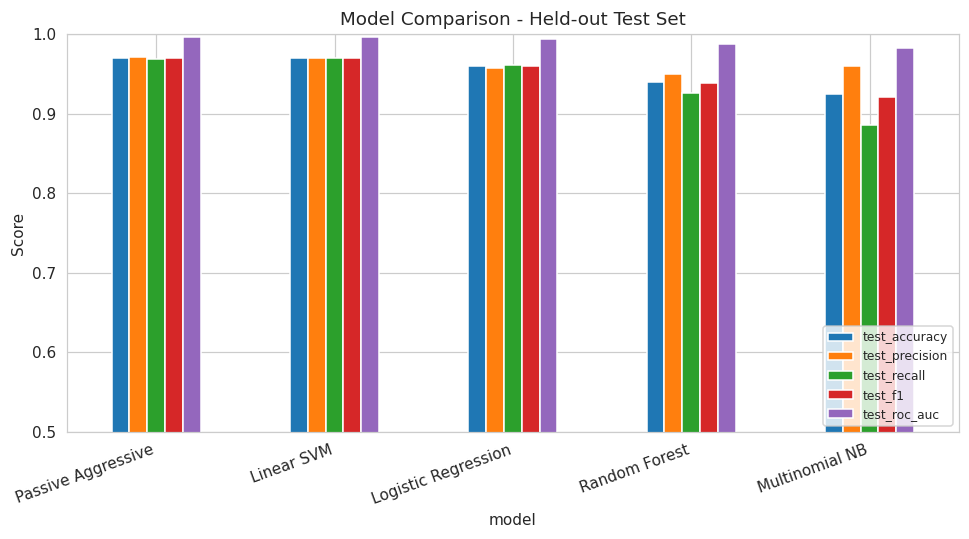

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results_df.set_index("model")[["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Model Comparison - Held-out Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../reports/model_comparison.png")
plt.show()

In [26]:
BEST_MODEL_NAME = results_df.iloc[0]["model"]
print(f"Best model by test F1-score: {BEST_MODEL_NAME}")

Best model by test F1-score: Passive Aggressive


## 8. Hyperparameter Tuning\n\nRandomizedSearchCV over the winning model's hyperparameters.

In [27]:
param_distributions = {
    "Logistic Regression": {
        "C": np.logspace(-2, 2, 20),
        "penalty": ["l2"],
        "solver": ["liblinear", "lbfgs"],
    },
    "Passive Aggressive": {
        "C": np.logspace(-2, 2, 20),
        "loss": ["hinge", "squared_hinge"],
    },
    "Linear SVM": {
        "C": np.logspace(-2, 2, 20),
        "loss": ["hinge", "squared_hinge"],
    },
    "Multinomial NB": {
        "alpha": np.linspace(0.01, 2.0, 20),
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 20, 40, 60],
        "min_samples_split": [2, 5, 10],
    },
}

base_model = models[BEST_MODEL_NAME].__class__(random_state=RANDOM_STATE) if "random_state" in models[BEST_MODEL_NAME].get_params() else models[BEST_MODEL_NAME].__class__()

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_distributions[BEST_MODEL_NAME],
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
t0 = time.time()
search.fit(X_train, y_train)
print(f"Search completed in {time.time() - t0:.1f}s")
print("Best params:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))

best_model = search.best_estimator_
tuned_preds = best_model.predict(X_test)
print("Tuned test F1:", round(f1_score(y_test, tuned_preds), 4))
print("Baseline (pre-tuning) test F1:", results_df[results_df['model'] == BEST_MODEL_NAME]['test_f1'].values[0])

Search completed in 7.1s
Best params: {'loss': 'squared_hinge', 'C': np.float64(0.7847599703514611)}
Best CV F1: 0.9718
Tuned test F1: 0.9697
Baseline (pre-tuning) test F1: 0.97


## 9. Model Evaluation

In [28]:
if hasattr(best_model, "predict_proba"):
    best_proba = best_model.predict_proba(X_test)[:, 1]
else:
    best_proba = best_model.decision_function(X_test)

final_preds = best_model.predict(X_test)

print(classification_report(y_test, final_preds, target_names=["Real (0)", "Fake (1)"]))

              precision    recall  f1-score   support

    Real (0)       0.97      0.97      0.97      2077
    Fake (1)       0.97      0.97      0.97      2050

    accuracy                           0.97      4127
   macro avg       0.97      0.97      0.97      4127
weighted avg       0.97      0.97      0.97      4127



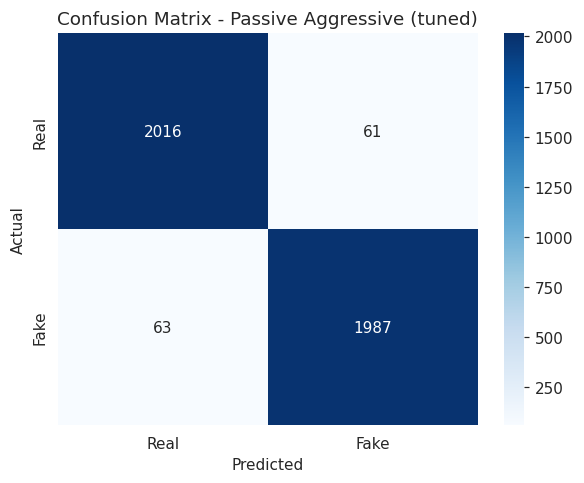

In [29]:
cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(f"Confusion Matrix - {BEST_MODEL_NAME} (tuned)")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png")
plt.show()

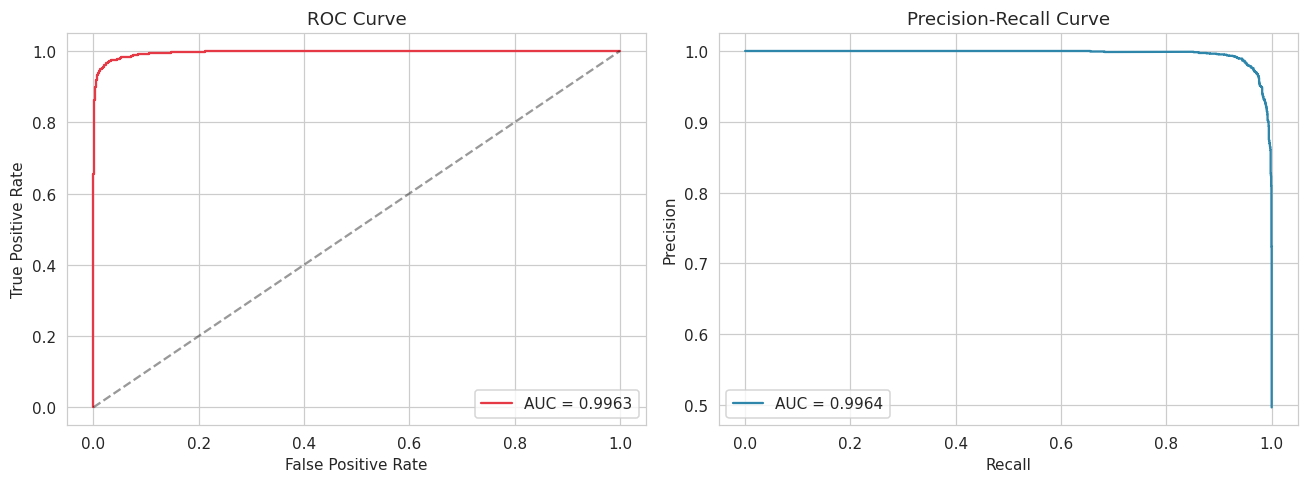

In [30]:
fpr, tpr, _ = roc_curve(y_test, best_proba)
roc_auc_val = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, best_proba)
pr_auc_val = auc(recall_vals, precision_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color="#E63946", label=f"AUC = {roc_auc_val:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

axes[1].plot(recall_vals, precision_vals, color="#2E86AB", label=f"AUC = {pr_auc_val:.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/roc_pr_curves.png")
plt.show()

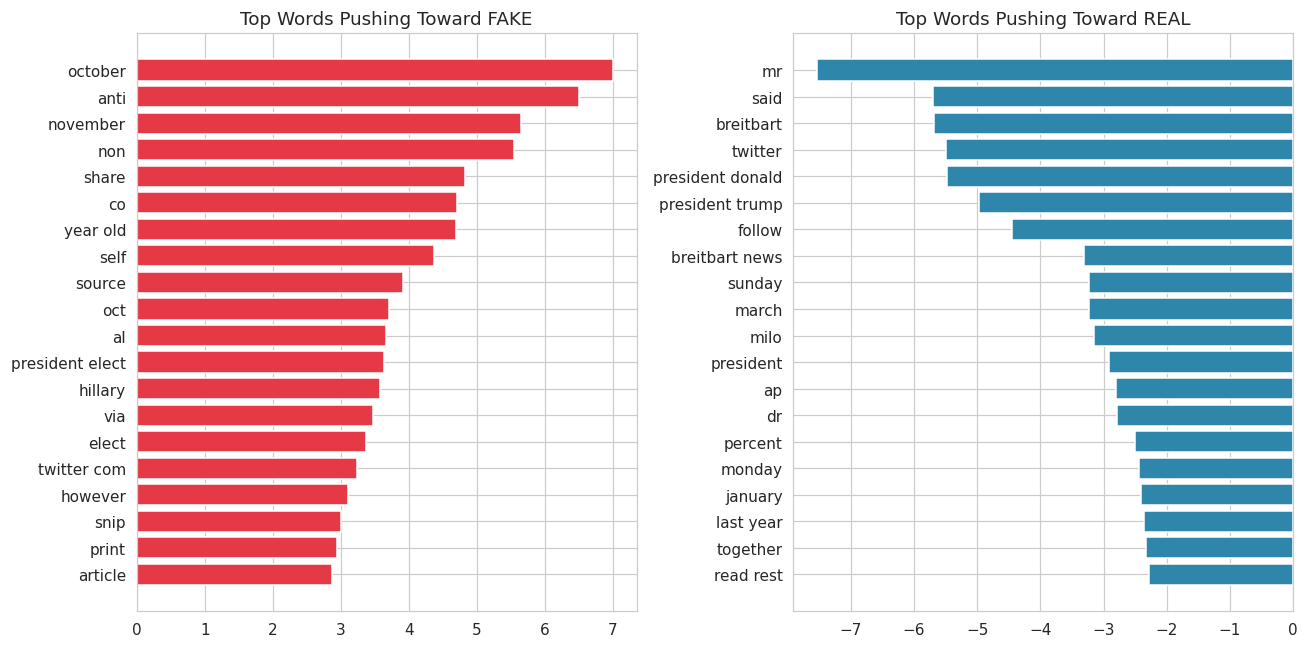

In [31]:
# Feature importance / top influential words -- only meaningful for linear models with coefficients
if hasattr(best_model, "coef_"):
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = best_model.coef_[0]
    top_pos_idx = np.argsort(coefs)[-20:][::-1]
    top_neg_idx = np.argsort(coefs)[:20]

    top_fake_words = pd.DataFrame({"word": feature_names[top_pos_idx], "weight": coefs[top_pos_idx]})
    top_real_words = pd.DataFrame({"word": feature_names[top_neg_idx], "weight": coefs[top_neg_idx]})

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].barh(top_fake_words["word"][::-1], top_fake_words["weight"][::-1], color="#E63946")
    axes[0].set_title("Top Words Pushing Toward FAKE")
    axes[1].barh(top_real_words["word"][::-1], top_real_words["weight"][::-1], color="#2E86AB")
    axes[1].set_title("Top Words Pushing Toward REAL")
    plt.tight_layout()
    plt.savefig("../reports/feature_importance.png")
    plt.show()
else:
    print(f"{BEST_MODEL_NAME} has no linear coefficients to display as feature importance.")

In [32]:
# False Positive / False Negative / Error analysis
test_df = pd.DataFrame({
    "text": X_test_text.values,
    "actual": y_test.values,
    "predicted": final_preds,
})
false_positives = test_df[(test_df["actual"] == 0) & (test_df["predicted"] == 1)]
false_negatives = test_df[(test_df["actual"] == 1) & (test_df["predicted"] == 0)]

print(f"False Positives (real news flagged as fake): {len(false_positives)} ({len(false_positives)/len(test_df)*100:.2f}% of test set)")
print(f"False Negatives (fake news missed):          {len(false_negatives)} ({len(false_negatives)/len(test_df)*100:.2f}% of test set)")
print()
print("Sample False Positive (real news the model misread as fake):")
print(false_positives["text"].iloc[0][:300] if len(false_positives) else "None found")
print()
print("Sample False Negative (fake news the model missed):")
print(false_negatives["text"].iloc[0][:300] if len(false_negatives) else "None found")

False Positives (real news flagged as fake): 61 (1.48% of test set)
False Negatives (fake news missed):          63 (1.53% of test set)

Sample False Positive (real news the model misread as fake):
gender study fake academic industry populated charlatan deranged activist gullible idiot pair enterprising hoaxer proved scientifically persuading academic journal publish paper claiming penis really male genital organ social construct paper published cogent social science multidisciplinary open acc

Sample False Negative (fake news the model missed):
elly warren melbourne travelling africa tragically died wednesday year old woman travelling africa last seen dropping bag beachside hostel found dead toilet cubicle elly warren melbourne expected return australia monday heading new zealand boyfriend holiday day set africa year old told father danger


## 10. Explainability (Logistic Regression)\n\nRegardless of which model wins overall, we train a dedicated Logistic Regression explainer since its coefficients map directly onto TF-IDF terms and give a transparent, auditable decision trail -- this is what powers the Explainable AI panel in the Streamlit app.

In [33]:
explainer_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
explainer_lr.fit(X_train, y_train)

explainer_preds = explainer_lr.predict(X_test)
print(f"Explainer LR test F1: {f1_score(y_test, explainer_preds):.4f}")

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = explainer_lr.coef_[0]

top_positive = sorted(zip(feature_names, coefs), key=lambda x: x[1], reverse=True)[:15]
top_negative = sorted(zip(feature_names, coefs), key=lambda x: x[1])[:15]

print("Top words -> FAKE:")
for w, c in top_positive:
    print(f"  {w:20s} {c:+.4f}")
print()
print("Top words -> REAL:")
for w, c in top_negative:
    print(f"  {w:20s} {c:+.4f}")

Explainer LR test F1: 0.9596
Top words -> FAKE:
  october              +7.0964
  november             +5.6462
  anti                 +5.4889
  hillary              +5.1107
  non                  +4.5586
  share                +4.5354
  year old             +4.3757
  clinton              +4.3400
  source               +3.9880
  self                 +3.6000
  co                   +3.3670
  al                   +3.1910
  old                  +2.9868
  elect                +2.9773
  president elect      +2.9707

Top words -> REAL:
  mr                   -11.0721
  said                 -9.5615
  twitter              -6.8961
  breitbart            -6.7189
  follow               -5.7554
  president donald     -5.4195
  president trump      -4.3316
  president            -4.2143
  breitbart news       -4.1652
  sunday               -3.9765
  mr trump             -3.3614
  percent              -3.3447
  friday               -3.0699
  saturday             -2.8152
  added                -2.8016


In [34]:
def explain_prediction(raw_text: str, top_k: int = 10):
    """Return the per-word contribution scores driving a single prediction, mirroring
    what the Streamlit app's Explainable AI panel will display."""
    cleaned = clean_text(raw_text)
    vec = vectorizer.transform([cleaned])
    proba = explainer_lr.predict_proba(vec)[0]
    pred = explainer_lr.predict(vec)[0]

    indices = vec.nonzero()[1]
    contributions = [(feature_names[i], vec[0, i] * coefs[i]) for i in indices]
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    return {
        "prediction": "Fake" if pred == 1 else "Real",
        "confidence": round(float(max(proba)), 4),
        "probability_fake": round(float(proba[1]), 4),
        "top_contributing_words": contributions[:top_k],
    }

sample_article = df["text"].iloc[test_df.index[0] if False else 0]
explain_prediction(sample_article)

{'prediction': 'Fake',
 'confidence': 0.9488,
 'probability_fake': 0.9488,
 'top_contributing_words': [('twitter', np.float64(-0.3244874881724334)),
  ('october', np.float64(0.31845318268955997)),
  ('fbi', np.float64(0.2515158117509071)),
  ('hillary', np.float64(0.19825709019266877)),
  ('follow', np.float64(-0.14058058141385238)),
  ('email', np.float64(0.13631548832815257)),
  ('committee', np.float64(-0.11529675446016566)),
  ('clinton', np.float64(0.09617304410794106)),
  ('percent', np.float64(-0.0879686746354267)),
  ('via', np.float64(0.08648660202698805))]}

## 11. Save Artifacts\n\nOnly the files the Streamlit app actually needs -- no scratch files.

In [35]:
import os
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# The Logistic Regression explainer doubles as the deployed model when it is the
# overall winner; otherwise we still ship it alongside the winning tuned model so the
# app's Explainable-AI panel always has coefficients to work with. Here we deploy the
# best TUNED model as the production classifier.
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
joblib.dump(explainer_lr, "../models/explainer_model.pkl")

# Labels are already binary (0/1) in the source data -- no LabelEncoder is required.
# We persist the mapping as plain JSON instead of an unnecessary pickle.
label_mapping = {"0": "Real", "1": "Fake"}
with open("../models/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)

evaluation_metrics = {
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "best_model_name": BEST_MODEL_NAME,
    "best_params": search.best_params_,
    "dataset_size": int(len(df)),
    "train_size": int(len(X_train_text)),
    "test_size": int(len(X_test_text)),
    "vectorizer_config": {
        "ngram_range": list(BEST_NGRAM_RANGE),
        "max_features": BEST_MAX_FEATURES,
        "min_df": BEST_MIN_DF,
        "max_df": BEST_MAX_DF,
        "vocabulary_size": len(vectorizer.vocabulary_),
    },
    "test_metrics": {
        "accuracy": round(accuracy_score(y_test, final_preds), 4),
        "precision": round(precision_score(y_test, final_preds), 4),
        "recall": round(recall_score(y_test, final_preds), 4),
        "f1_score": round(f1_score(y_test, final_preds), 4),
        "roc_auc": round(roc_auc_val, 4),
        "pr_auc": round(pr_auc_val, 4),
    },
    "model_comparison": results_df.to_dict(orient="records"),
    "confusion_matrix": cm.tolist(),
    "false_positive_count": int(len(false_positives)),
    "false_negative_count": int(len(false_negatives)),
}

with open("../reports/evaluation_metrics.json", "w") as f:
    json.dump(evaluation_metrics, f, indent=2)

print("Saved artifacts:")
for fname in ["best_model.pkl", "vectorizer.pkl", "explainer_model.pkl", "label_mapping.json"]:
    print(" -", fname)
print("Saved evaluation_metrics.json")
print()
print(json.dumps(evaluation_metrics["test_metrics"], indent=2))

Saved artifacts:
 - best_model.pkl
 - vectorizer.pkl
 - explainer_model.pkl
 - label_mapping.json
Saved evaluation_metrics.json

{
  "accuracy": 0.97,
  "precision": 0.9702,
  "recall": 0.9693,
  "f1_score": 0.9697,
  "roc_auc": 0.9963,
  "pr_auc": 0.9964
}


## Summary

- **Best performing model:** determined empirically above from `results_df`, then hyperparameter-tuned with `RandomizedSearchCV`.
- **Deployed artifacts:** `best_model.pkl`, `vectorizer.pkl`, `explainer_model.pkl`, `label_mapping.json`, `evaluation_metrics.json` — all consumed directly by the Phase 2 Streamlit application, with no re-typed or hard-coded numbers.
- **Next step:** Phase 2 — build `utils/text_preprocessing.py` and `utils/model_utils.py` from the exact functions defined here, then the Streamlit application itself.
